# Exercises

(Date - 26/May/2026)

In [101]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader
from torchmetrics import Accuracy
import torch.nn.functional as F
import functools
from tqdm.auto import tqdm
from timeit import default_timer as Timer


tqdm = functools.partial(tqdm, bar_format="{l_bar}\033[32m{bar:50}\033[0m{r_bar}")
device = "cuda" if torch.cuda.is_available() else "cpu"

1. What are 3 areas in industry where computer vision is currently being used?

Answer : 
1. Image recognition (e.g. face locks in phones)
2. AI CCTV surveillance (e.g. Object detection)
3. Satellite images (e.g. Analyzing the earth from space)<br>
<img src = "images/image_recognition.png" width = "350" height = "300" >
<img src = "images/object_detection.jpg" width = "350" height = "300">
<img src = "images/CCTV_object_detection.webp" width = "350" height = "300">


2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Answer:
It means that the model gets too precise in observing the noise (in data), instead of following the overall pattern. In simple terms, the model gets so good that its performance degrades.

<img src = "images/Overfitting_in_ML.png">



3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. Note: there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

Answer:

Ways to prevent over fitting are:
1. Using more training data: So that our model follows the overall pattern more, instead of the noise.
2. Applying regularization techniques : They discourages the model from getting too precise. It works by adding a penalty term to the loss during training. Example - Lasso(L1) and Ridge(L2)
3. Implementing early stopping : During training, if the model starts to get too precise, its train loss gets better (reduces) while the test loss degrades (increases). In such case, you should stop training before the difference between the train and test loss increases.

<img src = "images/EarlyStoppingInML.png" width = "500" height = "300">

4. Spend 20-minutes reading and clicking through the CNN Explainer website.
Upload your own example image using the "upload" button and see what happens in each layer of a CNN as your image passes through it.

Done!

5. Load the torchvision.datasets.MNIST() train and test datasets.

In [60]:
train_data = datasets.FashionMNIST(
    root="data/29.ipynb",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data/29.ipynb",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

6. Visualize at least 5 different samples of the MNIST training dataset.

In [61]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

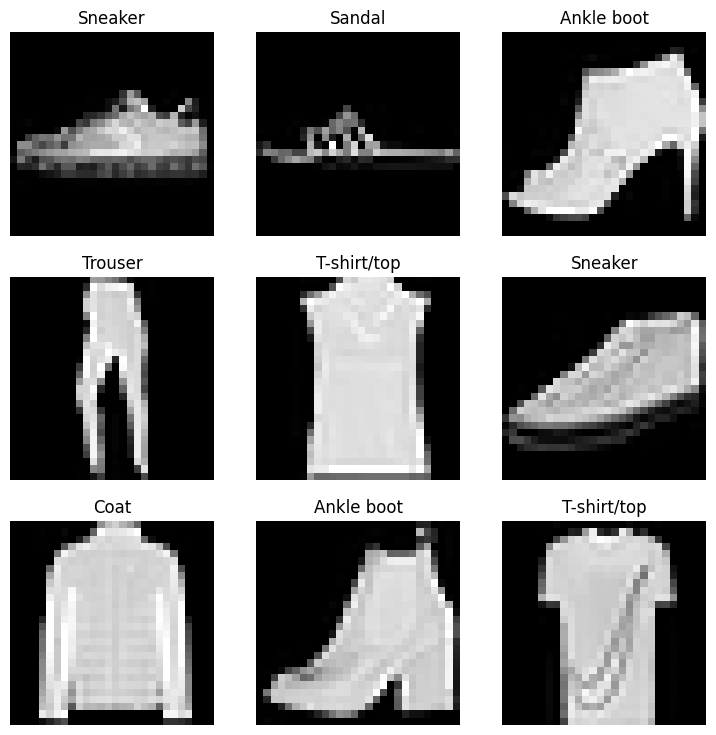

In [62]:
fig = plt.figure(figsize=(9,9))
for i in range(1,10):
    random_idx = random.randint(1,1000)
    img,label = train_data[random_idx]
    fig.add_subplot(3,3,i)
    plt.title(class_names[label])
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis(False)

7. Turn the MNIST train and test datasets into dataloaders using torch.utils.data.DataLoader, set the batch_size=32.

In [63]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    batch_size=BATCH_SIZE,
    dataset=train_data,
    shuffle=False)

test_dataloader = DataLoader(
    batch_size=BATCH_SIZE,
    dataset=test_data,
    shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x192f3af0910>,
 <torch.utils.data.dataloader.DataLoader at 0x192f4049310>)

The rest of the solution may not follow the exercise requirements. I am doing this at my will.

In [111]:
class model(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_units):
        super(model, self).__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=(3,3),
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units)   ,                                                                                         
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=(3,3),
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=(3,3),
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=(3,3),
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x=self.conv_block_2(x)
        x=self.classifier(x)
        return F.log_softmax(x)
            
    
Model = model(input_shape=1, output_shape=len(class_names), hidden_units=32).to(device)

In [112]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=Model.parameters(),
                            lr=0.001)

accuracy_fn = Accuracy(task="multiclass", num_classes=10)

In [113]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    
    length = len(data_loader)
    loss, acc = 0, 0

    model.train()
    for batch, (img, label) in enumerate(data_loader):
        img, label = img.to(device), label.to(device)

        pred = model(img)
        temp_loss = loss_fn(pred, label)

        loss += temp_loss
        acc += accuracy_fn(pred, label)

        optimizer.zero_grad()
        temp_loss.backward()
        optimizer.step()
    
    loss = loss / length
    acc = (acc / length) * 100

    print(f"Train Loss: {loss:.4f} | Train accuracy: {acc:.2f}%")


In [116]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              device: torch.device):
    
    length = len(data_loader)
    loss, acc = 0, 0

    model.eval()
    with torch.inference_mode():
        for batch, (img, label) in enumerate(data_loader):
            pred = model(img)
            temp_loss = loss_fn(pred, label)
            loss+=temp_loss
            acc+=accuracy_fn(pred, label)
    
    loss = loss / length
    acc = acc /  length

    print(f"Test Loss: {loss:.4f} | Test accuracy: {acc:.2f}")


In [118]:
epochs = 12
train_time_start = Timer()

for epoch in tqdm(range(epochs)):
    train_step(model=Model,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

train_time_end = Timer()
total_train_time = train_time_end - train_time_start
total_train_time


  0%|                                                  | 0/12 [00:00<?, ?it/s]C:\Users\user\AppData\Local\Temp\ipykernel_10016\1972313432.py:55: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)
  8%|████▏                                             | 1/12 [01:50<20:16, 110.59s/it]

Train Loss: 0.1652 | Train accuracy: 93.94%


 17%|████████▎                                         | 2/12 [03:17<16:07, 96.79s/it] 

Train Loss: 0.1623 | Train accuracy: 93.99%


 25%|████████████▌                                     | 3/12 [04:44<13:48, 92.08s/it]

...

 92%|█████████████████████████████████████████████▊    | 11/12 [16:13<01:26, 86.18s/it]

Train Loss: 0.1361 | Train accuracy: 95.03%


100%|██████████████████████████████████████████████████| 12/12 [17:40<00:00, 88.36s/it]

Train Loss: 0.1348 | Train accuracy: 94.94%


1060.4691605999997

In [ ]:
test_time_start = Timer()

test_step(model=Model,
               data_loader=test_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

test_time_end = Timer()
total_test_time = test_time_end - test_time_start
total_test_time

C:\Users\user\AppData\Local\Temp\ipykernel_10016\4064047516.py:54: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


Test Loss: 0.4252 | Test accuracy: 0.85


3.685923900000489